In [11]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import anndata as ad

from scipy.stats import gamma, expon, poisson
from scipy import sparse
import statsmodels.api as sm

import importlib

import plotting_funs

In [12]:
prop_cycle = plotting_funs.set_mpl_attributes()

# Import Data:

In [13]:
grn_file = "KeggoRo"

In [4]:
norman_data = sc.read_h5ad("../Data/Experimental/Norman19/perturb_norm.h5ad")
replogle_data = sc.read_h5ad("../Data/Experimental/Replogle22/perturb_norm.h5ad")

KeyboardInterrupt: 

In [6]:
norman_data = norman_data[norman_data.obs["perturbation"]=="ctrl"]
replogle_data = replogle_data[replogle_data.obs["perturbation"]=="ctrl"]

In [30]:
import sys
sys.path.append("..")
from Prep_Data import pgrins_prepare_output
grins_data_full,adata_list = pgrins_prepare_output.grins_racipe_to_adata(grn_file,f"../Data/SimulResults_Racipe/{grn_file}/001/{grn_file}_steadystate_solutions_001",split_sinks=True)
sc.pp.calculate_qc_metrics(grins_data_full,percent_top=[20],inplace=True,log1p=True)

There are 2429104 zero entries (0.453% of all entries).
Out of 5364 genes, there are 14 genes with more than 1.0% of entries being negative, and 7 genes with more than 1.0% of entries being NaN.
There are also 89 genes that have a mean expression of >10000.
Create AnnData object...


In [31]:
grins_data = sc.read_h5ad(f"../Data/Projects/{grn_file}/001/perturb_norm_ctrl.h5ad")
#grins_data = grins_data[grins_data.obs["perturbation"]=="ctrl"]

# Control Data Comparison:

In [73]:
cs = [0,1,2]
names = ["Norman19","Replogle22","GRiNS with missingness filter"]
data = [norman_data,replogle_data,grins_data]

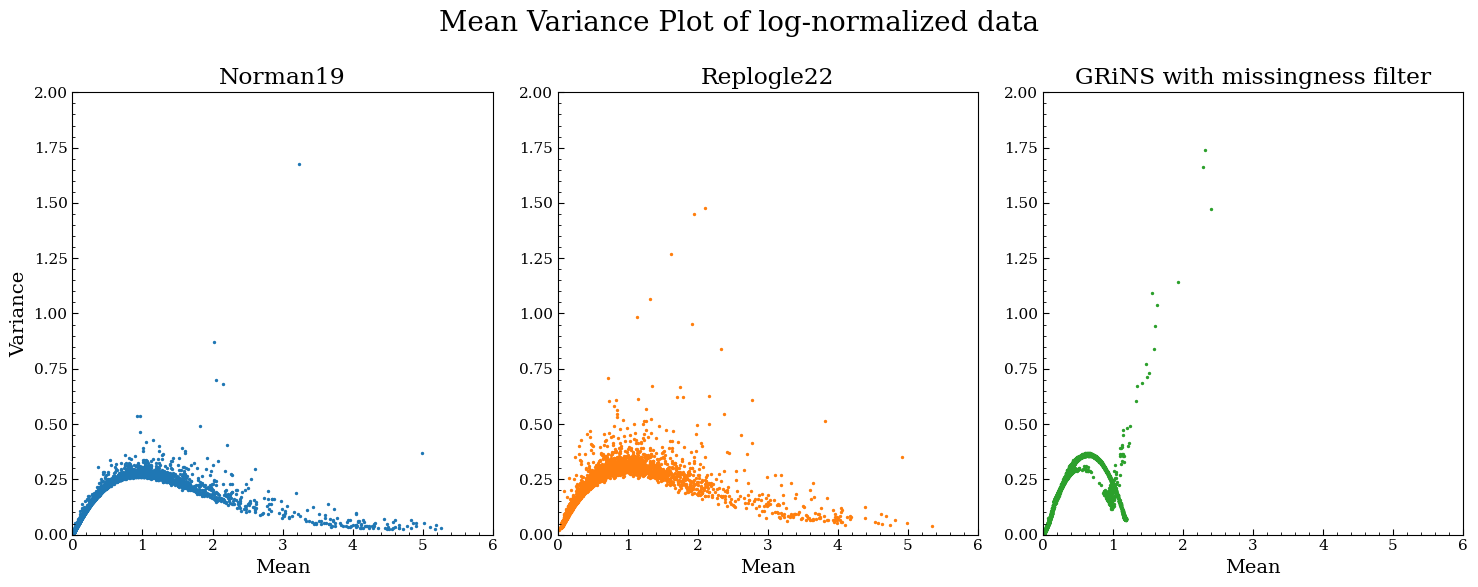

In [78]:
fig, axs = plt.subplots(1,3,figsize=(15,6))
#cs = [0,1,6]
axs[0].set_ylabel("Variance")
plt.suptitle("Mean Variance Plot of log-normalized data")
for i, adata in zip(range(len(cs)),data):#,replogle_data,grins_data]:
    a_mean = np.asarray(data[i].layers["log1p"].mean(axis=0)).squeeze()
    a_squared = data[i].layers["log1p"].multiply(data[i].layers["log1p"])
    a_var = np.asarray(np.mean(a_squared,axis=0)).squeeze()-a_mean*a_mean
    axs[i].scatter(a_mean,a_var,s=2,c=prop_cycle[cs[i]])
    axs[i].set_title(f"{names[i]}")
    axs[i].set_xlabel("Mean",fontsize=14)
    axs[i].set_xlim(0,6)
    axs[i].set_ylim(0,2)
plt.tight_layout()
plt.savefig(f"../Prep_Data/Plots/{grn_file}/mean_variance.png")
plt.show()

# Missingness Analysis:

## Across Genes:

In [79]:
from tqdm import tqdm
mean_nzs = []
for i in range(len(data)):
    ds = data[i]
    layer = ds.layers["log1p"].tocsc()
    non_zero_entries = np.split(layer.indices,layer.indptr[1:-1])
    mean_nz = []
    for j in tqdm(range(len(non_zero_entries))):
        non_zero_exprs = (layer[non_zero_entries[j],j]).todense().T
        if non_zero_exprs.shape[1] < 1:
            mean_nz.append(0)
            continue
        mean_nz.append(np.mean(non_zero_exprs))
    mean_nzs.append(mean_nz)

100%|██████████| 5364/5364 [00:13<00:00, 391.14it/s]


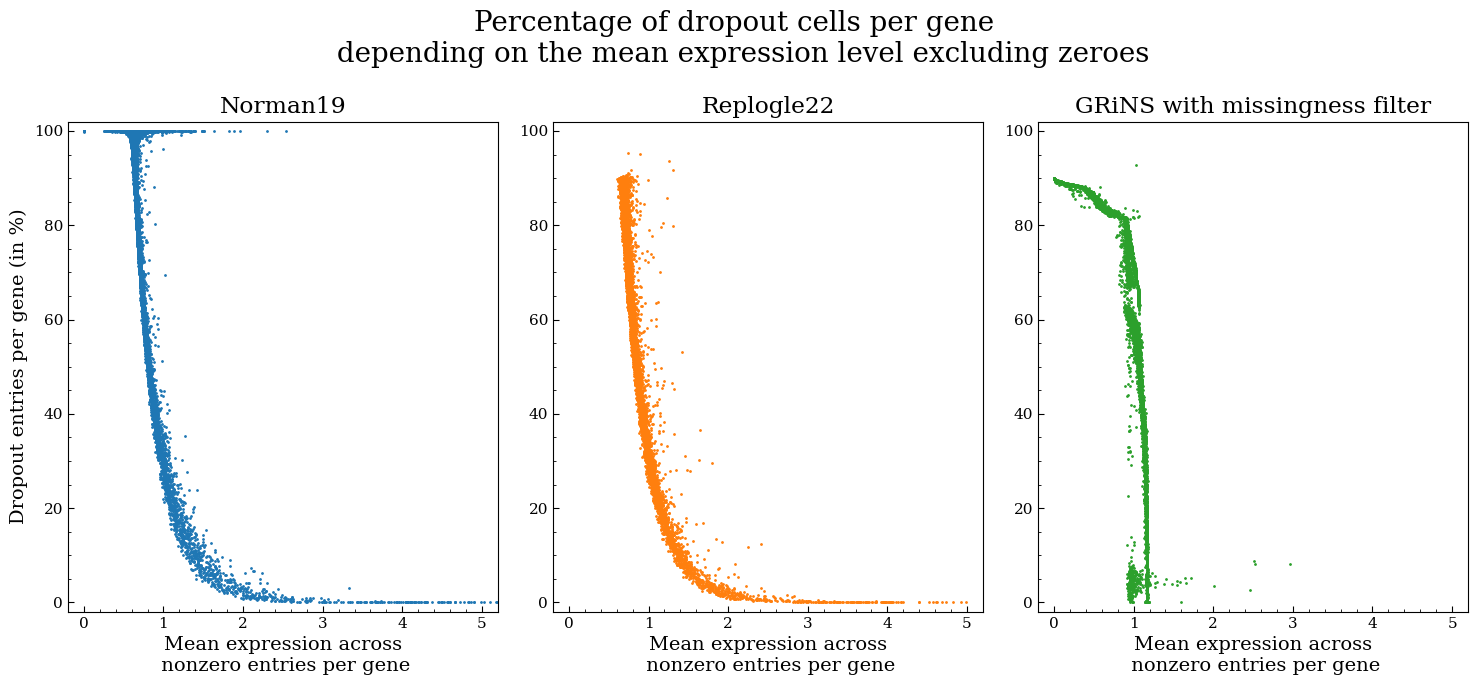

In [37]:

fig, axs = plt.subplots(1,3,figsize=(15,7))
axs[0].set_ylabel("Dropout entries per gene (in %)")

for i in range(len(axs)):
    ax = axs[i]
    ax.scatter(mean_nzs[i],data[i].var["pct_dropout_by_counts"],s=1,color=prop_cycle[cs[i]])
    ax.set_xlim(-0.2,5.2)
    ax.set_ylim(-2,102)
    ax.set_xlabel("Mean expression across\n nonzero entries per gene")
    ax.set_title(names[i])

plt.suptitle("Percentage of dropout cells per gene \n depending on the mean expression level excluding zeroes")
plt.tight_layout()
plt.savefig(f"../Prep_Data/Plots/{grn_file}/missingness_genewise_nzmean.png")
plt.show()

/tmp/ipykernel_670375/1108675903.py:15: RuntimeWarning: invalid value encountered in divide
  replogle_scaling_factor = np.nanmean(replogle_y/dense_replogle_y) # PDF was fitted on dense replogle, but for comparison of Norman & Replogle, actual counts are better -> scale PDF by this factor


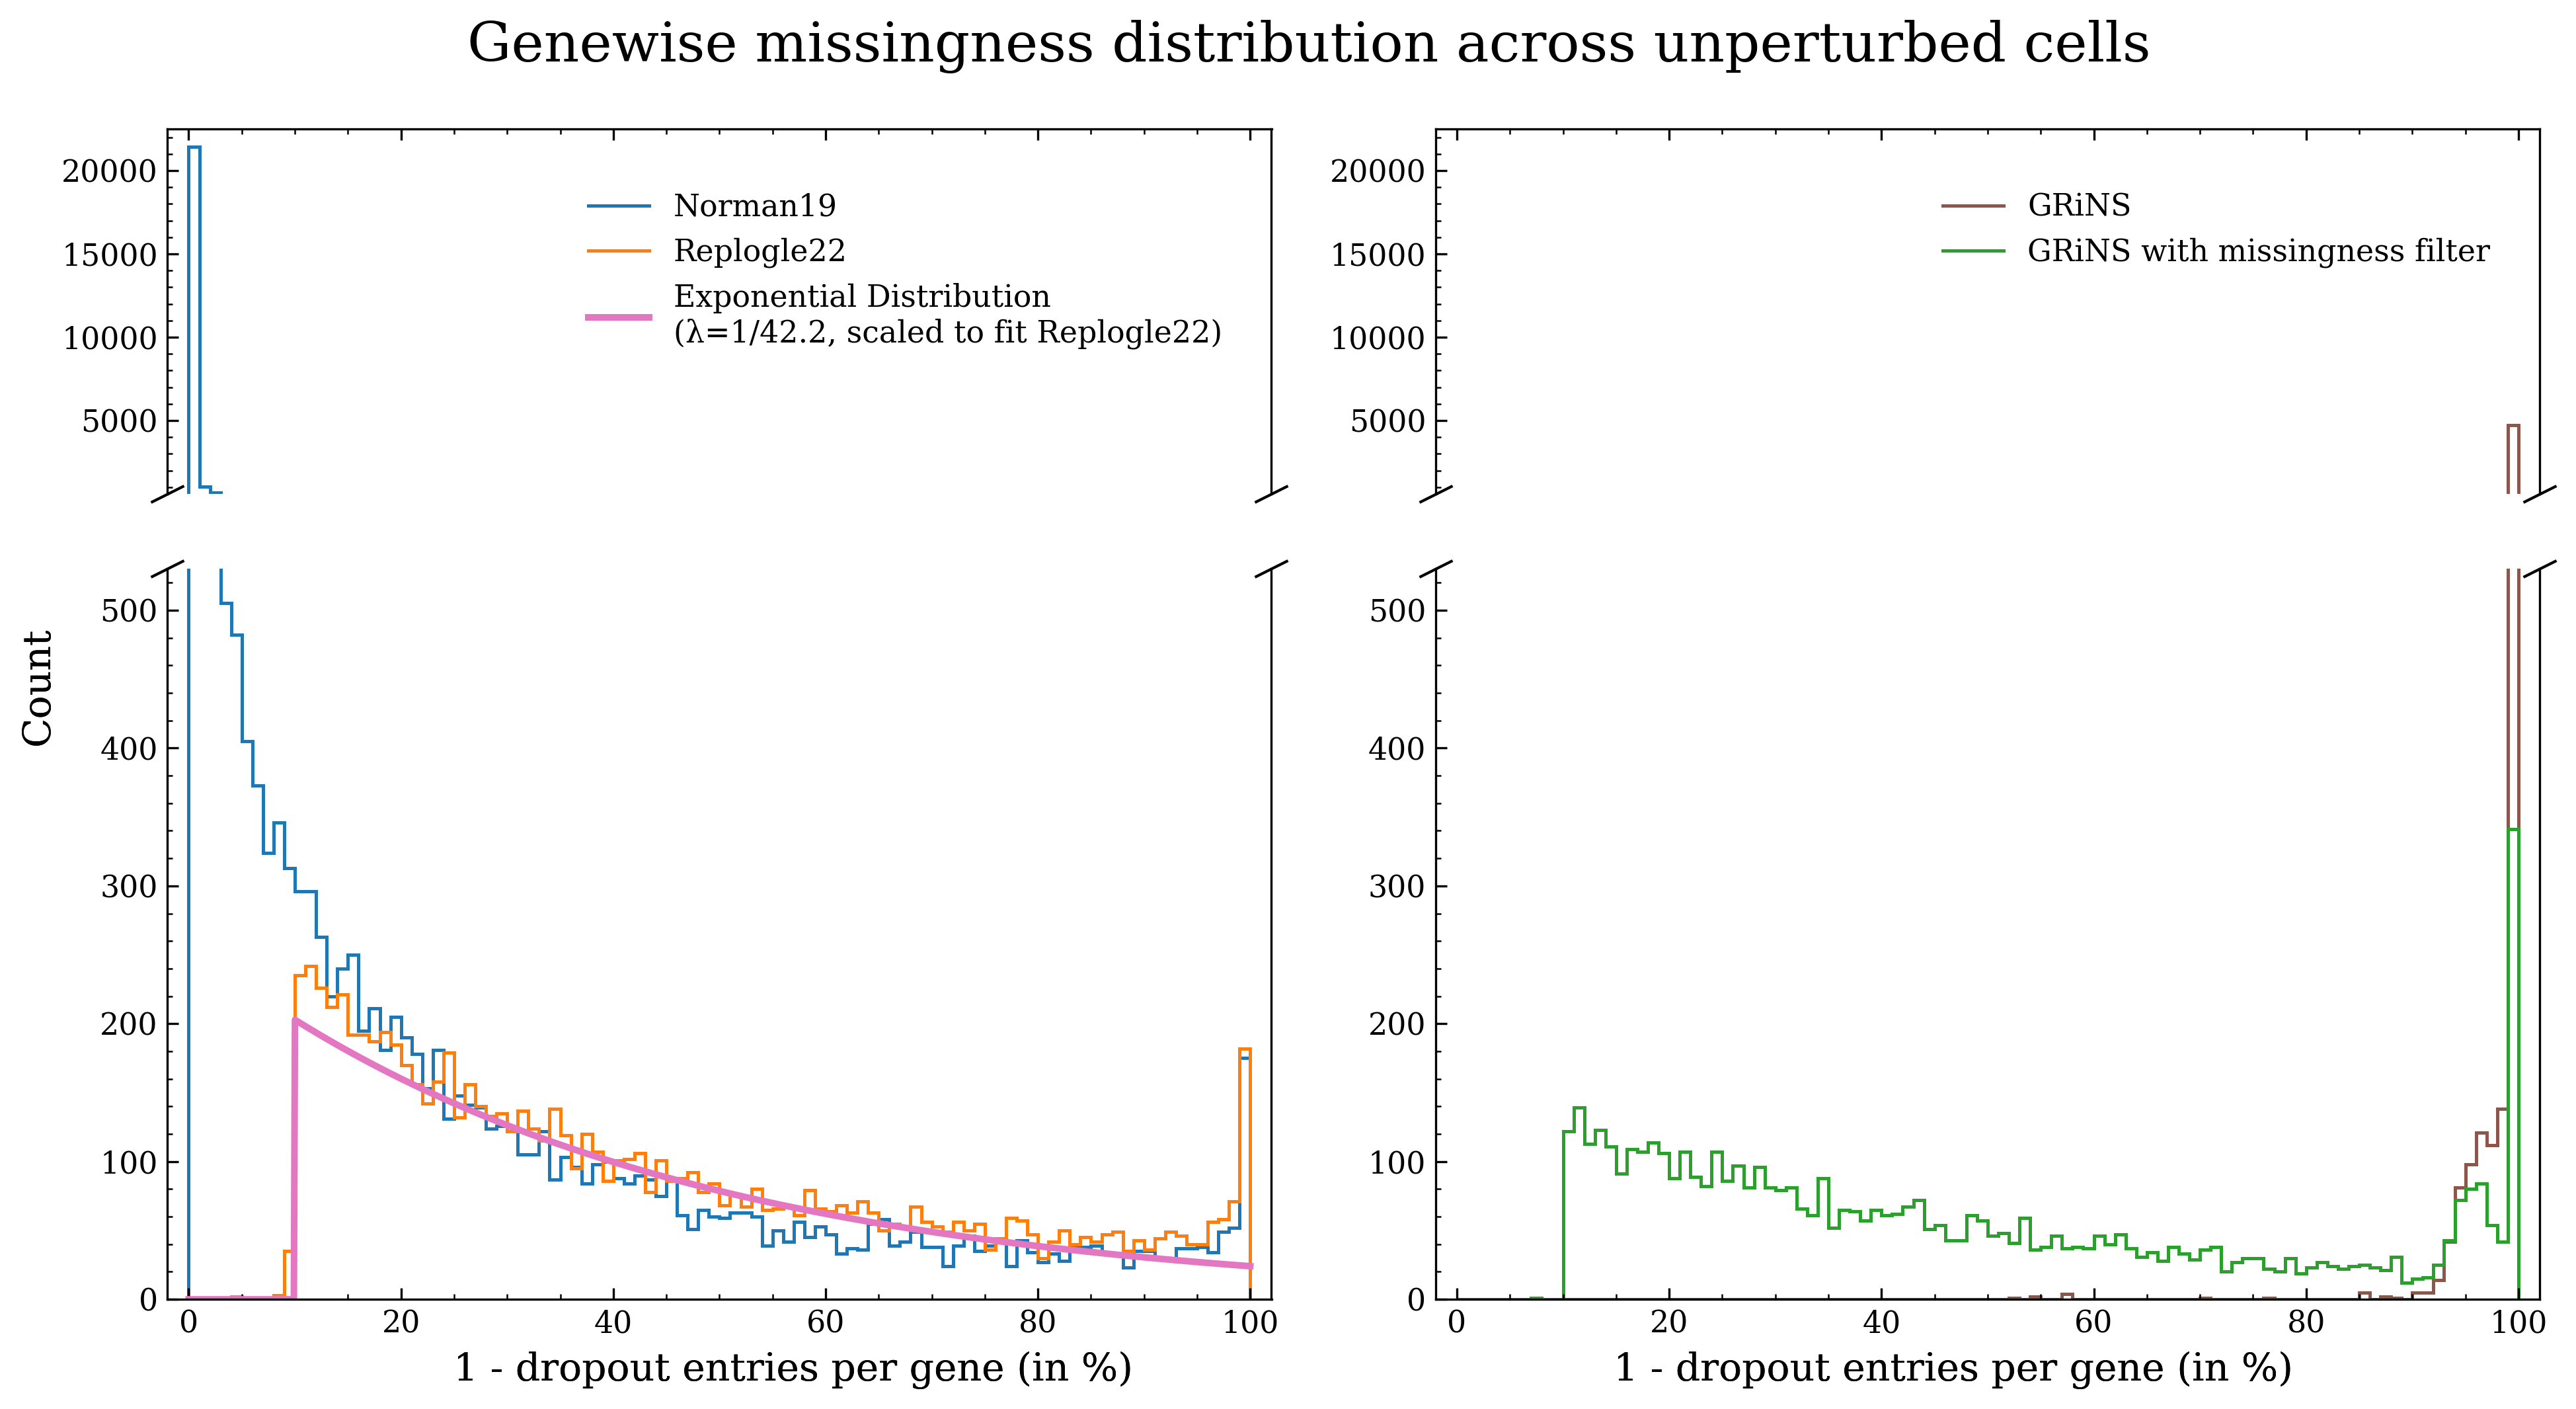

In [59]:
fig, axs = plt.subplots(2, 2, sharex="col",figsize=(13,7),dpi=300,height_ratios=[1,2])
fig.subplots_adjust(hspace=0.05)  # adjust space between Axes

bins = 100
replogle_y, replogle_x = np.histogram(list(100-replogle_data.var["pct_dropout_by_counts"]),bins=bins,range=(0,100))
norman_y, norman_x = np.histogram(list(100-norman_data.var["pct_dropout_by_counts"]),bins=bins,range=(0,100))

grins_y, grins_x = np.histogram(list(100-grins_data_full.var["pct_dropout_by_counts"]),bins=bins,range=(0,100))
miss_grins_y, miss_grins_x = np.histogram(list(100-grins_data.var["pct_dropout_by_counts"]),bins=bins,range=(0,100))

dense_replogle_y, dense_replogle_x = np.histogram(list(100-replogle_data.var["pct_dropout_by_counts"]),bins=bins,range=(0,100),density=True)
pdf_mean = np.mean(100-replogle_data.var["pct_dropout_by_counts"])
pdf_fitted = expon.pdf(np.linspace(0,100,1000),loc=10,scale=pdf_mean)

replogle_scaling_factor = np.nanmean(replogle_y/dense_replogle_y) # PDF was fitted on dense replogle, but for comparison of Norman & Replogle, actual counts are better -> scale PDF by this factor
lw = 1.2
for j in range(2):
    ax1 = axs[0,j]
    ax2 = axs[1,j]
    if j == 0:
        ax1.stairs(norman_y,norman_x,label="Norman19",color=prop_cycle[0],lw=lw) # fill=True, alpha=0.7(?)
        ax2.stairs(norman_y,norman_x,color=prop_cycle[0],lw=lw)

        ax1.stairs(replogle_y,replogle_x, label="Replogle22",color=prop_cycle[1],lw=lw)
        ax2.stairs(replogle_y,replogle_x,color=prop_cycle[1],lw=lw)
    
        ax2.plot(np.linspace(0,100,1000),replogle_scaling_factor*pdf_fitted,color=prop_cycle[6],lw=2*lw)
        ax1.plot(np.linspace(0,100,1000),replogle_scaling_factor*pdf_fitted,color=prop_cycle[6],lw=2*lw,label=f"Exponential Distribution \n(λ=1/{np.round(pdf_mean,2)}, scaled to fit Replogle22)")

    else:
        ax1.stairs(grins_y,grins_x, label="GRiNS",color=prop_cycle[5],lw=lw)
        ax2.stairs(grins_y,grins_x,color=prop_cycle[5],lw=lw)

        ax1.stairs(miss_grins_y,miss_grins_x, label="GRiNS with missingness filter",color=prop_cycle[2],lw=lw)
        ax2.stairs(miss_grins_y,miss_grins_x,color=prop_cycle[2],lw=lw)


    ax2.set_ylim(0,530)
    ax1.set_ylim(580,22500)

    ax1.spines.bottom.set_visible(False)
    ax2.spines.top.set_visible(False)
    ax1.xaxis.tick_top()
    ax1.tick_params(labeltop=False)  # don't put tick labels at the top
    ax2.xaxis.tick_bottom()

    d = .5  # proportion of vertical to horizontal extent of the slanted line
    kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
                linestyle="none", color='k', mec='k', mew=1, clip_on=False)
    ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

    fig.text(0.3, 0, '1 - dropout entries per gene (in %)', ha='center')
    fig.text(0.75, 0, '1 - dropout entries per gene (in %)', ha='center')
    fig.text(0, 0.5, 'Count', va='center', rotation='vertical')
    ax1.legend(loc="upper right",bbox_to_anchor=(0.98,0.9))
    plt.suptitle("Genewise missingness distribution across unperturbed cells")
plt.tight_layout()
plt.savefig(f"../Prep_Data/Plots/{grn_file}/missingness_genewise.png")
plt.show()

## Across Cells:

In [46]:
cs = [0,1,2,5]
names = ["Norman19","Replogle22","GRiNS with missingness filter","GRiNS"]
data = [norman_data,replogle_data,grins_data, grins_data_full]

/storage/mi/sommereg03/vbsc_2/lib/python3.13/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


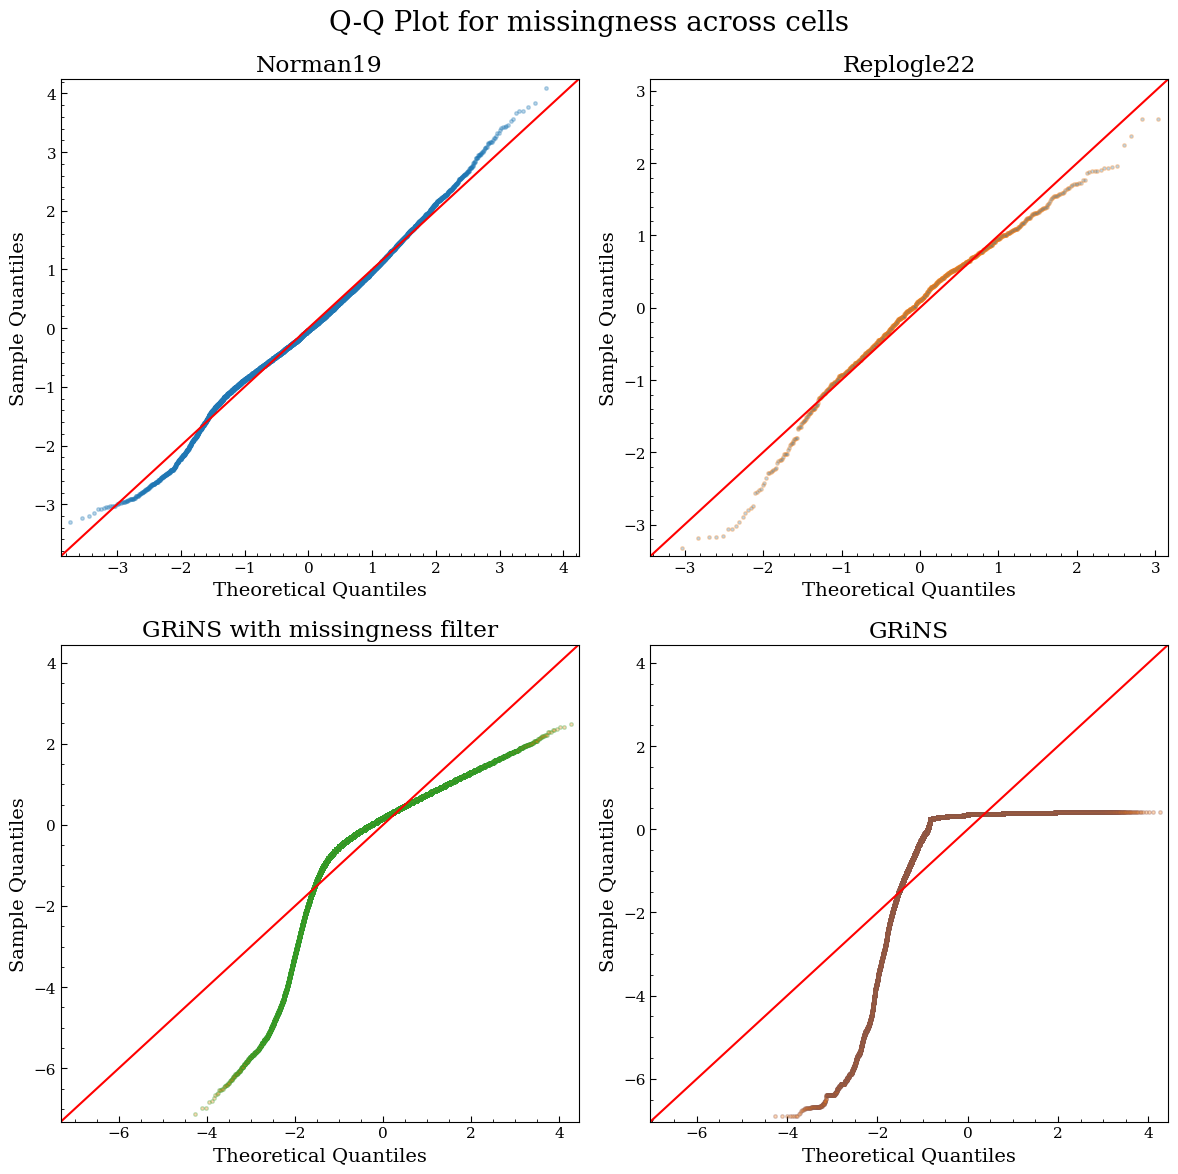

In [48]:
pps = [sm.ProbPlot(norman_data.obs["n_genes_by_counts"], fit=True),
    sm.ProbPlot(replogle_data.obs["n_genes_by_counts"], fit=True),
    sm.ProbPlot(grins_data.obs["n_genes_by_counts"], fit=True),
    sm.ProbPlot(grins_data_full.obs["n_genes_by_counts"], fit=True)]
fig, axs = plt.subplots(2,2,figsize=(12,12))
for i in range(2):
    for j in range(2):
        ax = axs[i,j]
        qq = pps[2*i+j].qqplot(ax=ax,line='45',fmt='r--',lw=1,marker='.', markerfacecolor=prop_cycle[cs[i]], markeredgecolor=prop_cycle[cs[2*i+j]], alpha=0.3,markersize=5)#,axs=[0,0])
        #sm.qqline(qq.axes[0], line='45', fmt='r--',lw=1)
        ax.set_title(names[2*i+j])#f"Q-Q Plot for missingness \n across cells of {names[i]}")
plt.suptitle("Q-Q Plot for missingness across cells")
plt.tight_layout()
plt.savefig(f"../Prep_Data/Plots/{grn_file}/missingness_cellwise_qq_all.png")
plt.show()


# Not perfectly normal, but approximatively so
# uGRiNS (esp. m+uGRiNS) has two approx-normal sections

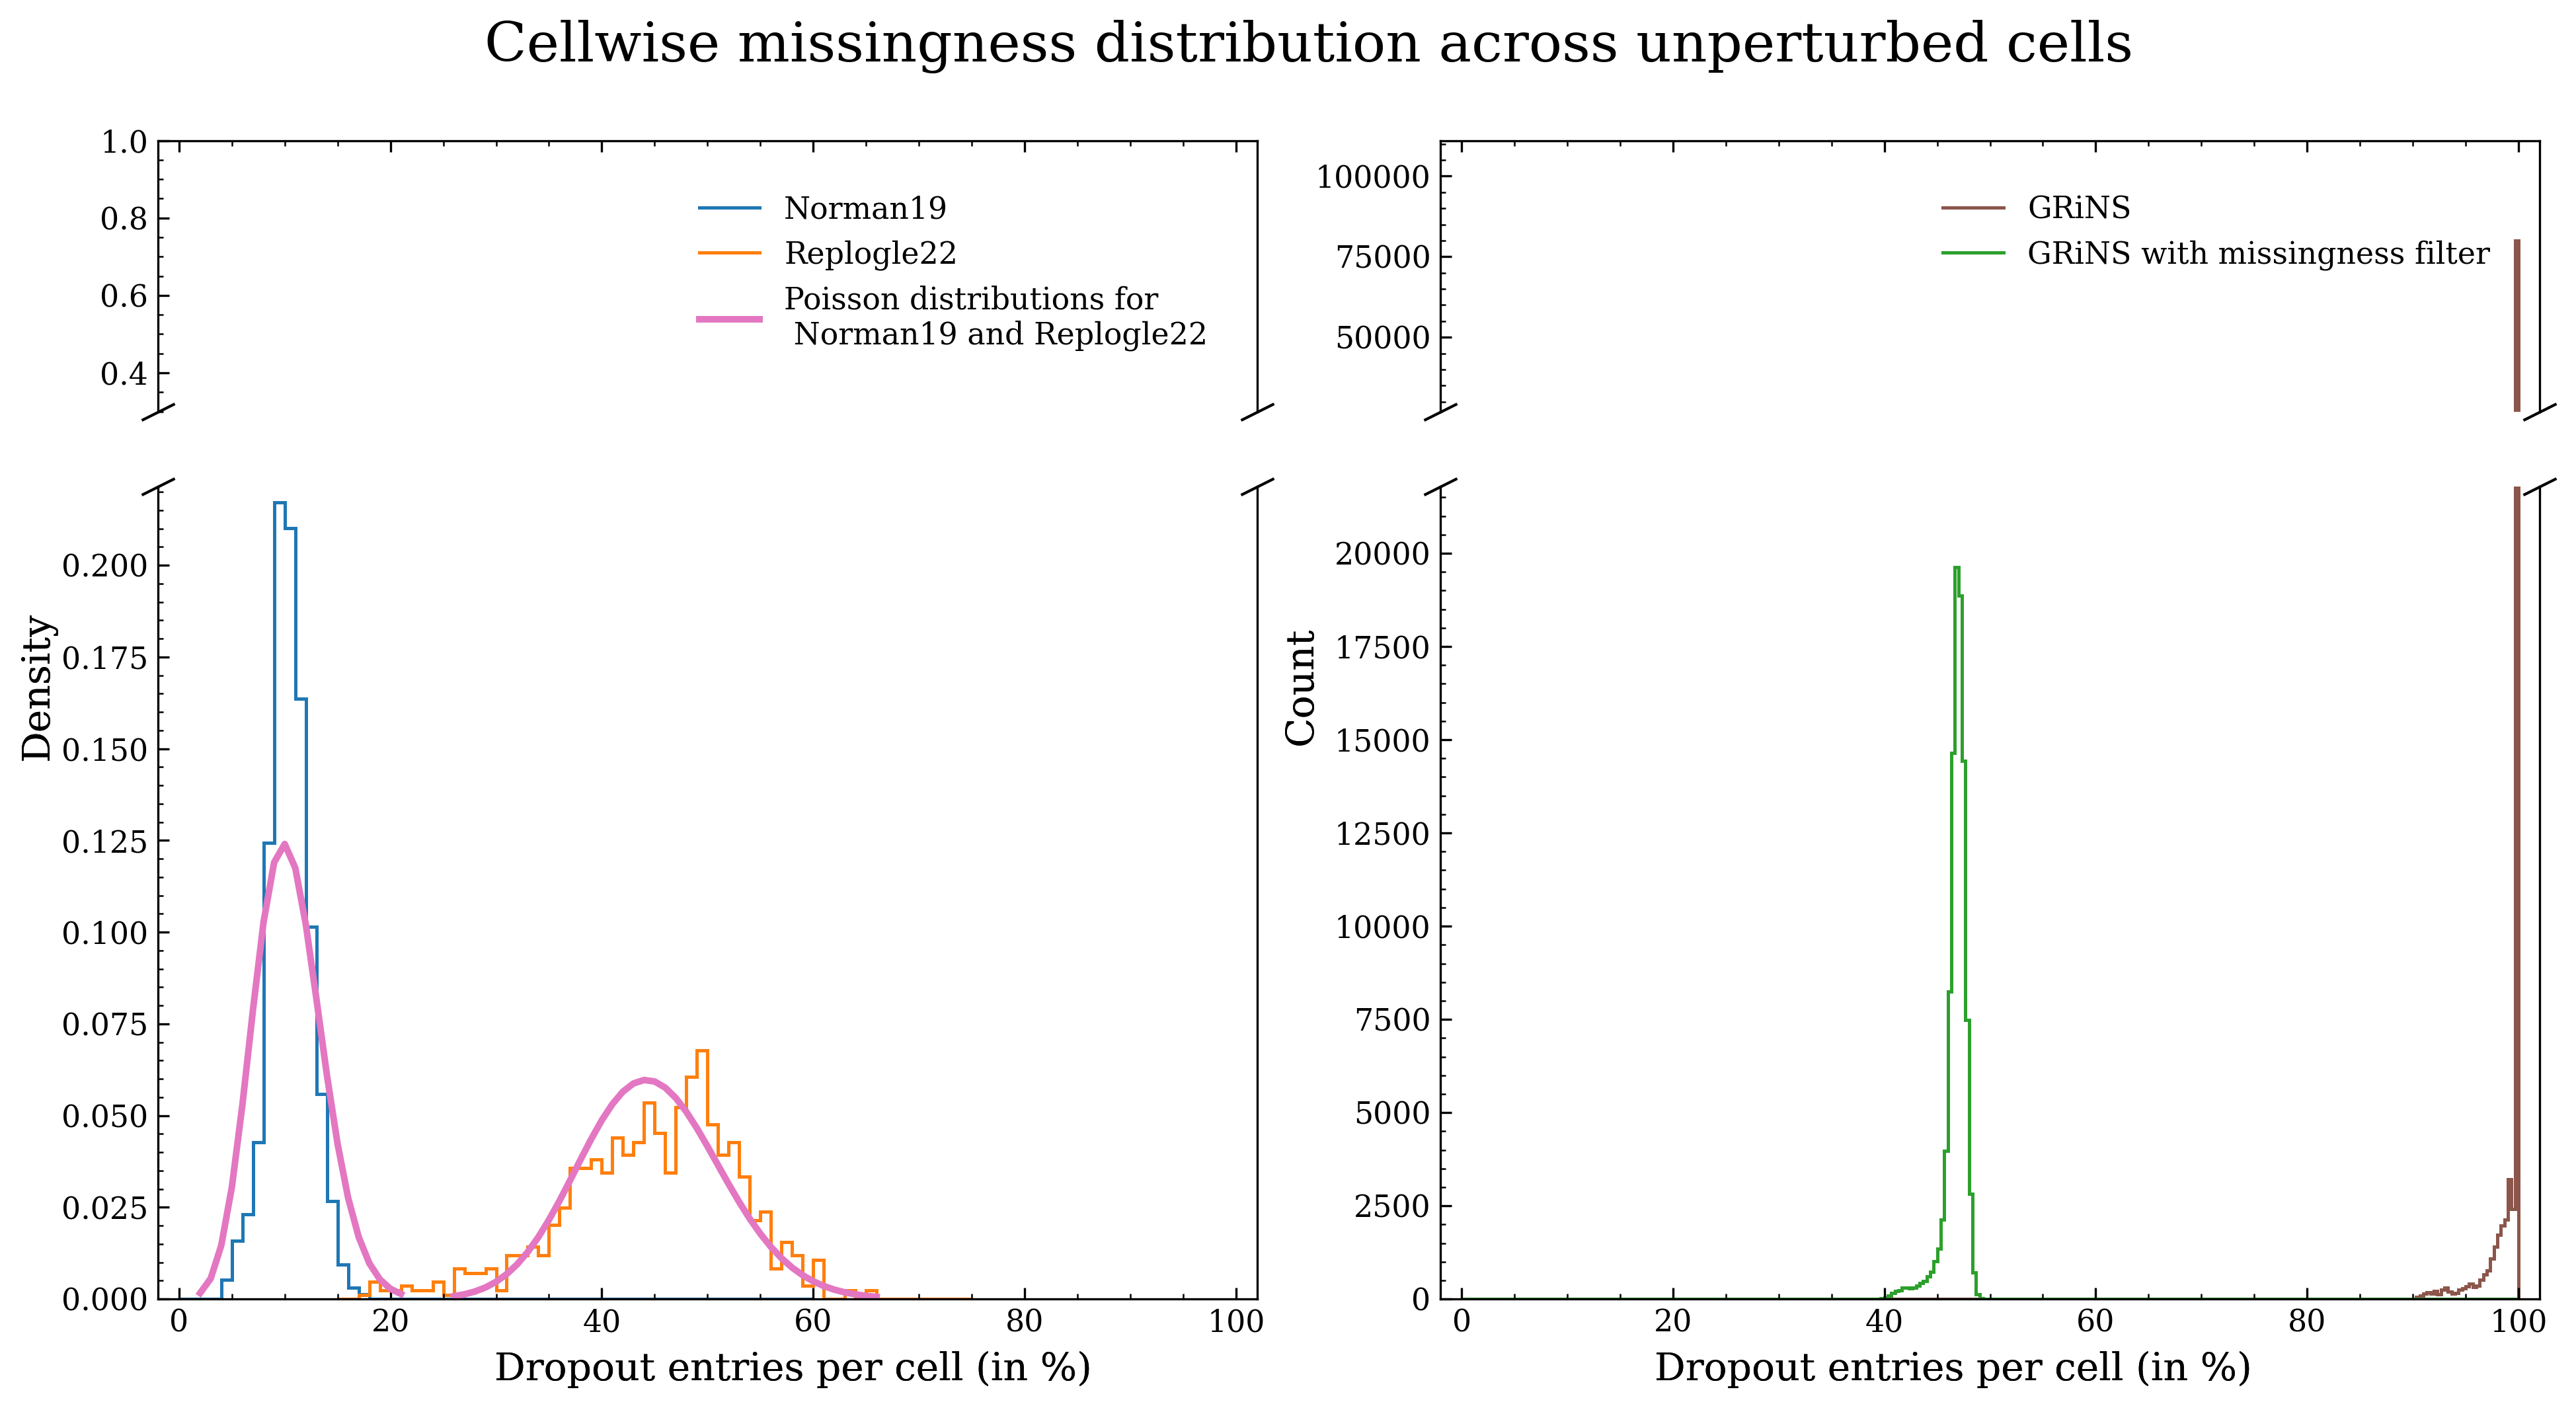

In [58]:
fig, axs = plt.subplots(2, 2, sharex="col",figsize=(13,7),dpi=300,height_ratios=[1,3])
fig.subplots_adjust(hspace=0.05)  # adjust space between Axes

bins = 60
replogle_y, replogle_x = np.histogram(list(100*(replogle_data.obs["n_genes_by_counts"]/replogle_data.shape[1])),bins=bins,range=(15,75),density=True)
norman_y, norman_x = np.histogram(list(100*(norman_data.obs["n_genes_by_counts"]/norman_data.shape[1])),bins=bins,range=(0,60),density=True)

grins_y, grins_x = np.histogram(list(100*(grins_data_full.obs["n_genes_by_counts"]/grins_data_full.shape[1])),bins=5*bins,range=(0,100))
miss_grins_y, miss_grins_x = np.histogram(list(100*(grins_data.obs["n_genes_by_counts"]/grins_data.shape[1])),bins=5*bins,range=(0,100))

norman_lamb = np.mean(list(100*(norman_data.obs["n_genes_by_counts"]/norman_data.shape[1])))
norman_poisx = np.arange(poisson.ppf(0.001, norman_lamb),poisson.ppf(0.999, norman_lamb))
norman_pois = poisson.pmf(norman_poisx,norman_lamb)
rep_lamb = np.mean(list(100*(replogle_data.obs["n_genes_by_counts"]/replogle_data.shape[1])))
rep_poisx = np.arange(poisson.ppf(0.001, rep_lamb),poisson.ppf(0.999, rep_lamb))
rep_pois = poisson.pmf(rep_poisx,rep_lamb)

for j in range(2):
    ax1 = axs[0,j]
    ax2 = axs[1,j]
    if j == 0:
        
        ax1.stairs(norman_y,norman_x,label="Norman19",color=prop_cycle[0],lw=lw)
        ax2.stairs(norman_y,norman_x,color=prop_cycle[0],lw=lw)

        ax1.stairs(replogle_y,replogle_x, label="Replogle22",color=prop_cycle[1],lw=lw)
        ax2.stairs(replogle_y,replogle_x,color=prop_cycle[1],lw=lw)
        
        ax1.plot(norman_poisx,norman_pois,label=f"Poisson distributions for \n Norman19 and Replogle22",color=prop_cycle[6],lw=2*lw)
        ax2.plot(norman_poisx,norman_pois,color=prop_cycle[6],lw=2*lw)
        ax1.plot(rep_poisx,rep_pois,color=prop_cycle[6],lw=2*lw)
        ax2.plot(rep_poisx,rep_pois,color=prop_cycle[6],lw=2*lw)

               
    else:
        ax1.stairs(grins_y,grins_x, label="GRiNS",color=prop_cycle[5],lw=lw)
        ax2.stairs(grins_y,grins_x,color=prop_cycle[5],lw=lw)

        ax1.stairs(miss_grins_y,miss_grins_x, label="GRiNS with missingness filter",color=prop_cycle[2],lw=lw)
        ax2.stairs(miss_grins_y,miss_grins_x,color=prop_cycle[2],lw=lw)
        
    if j == 1:
        ax2.set_ylim(0,21800)
        ax1.set_ylim(27000,111000)
    else:
        ax1.set_ylim(0.3,1)
    ax1.set_xlim(-2,102)

    ax1.spines.bottom.set_visible(False)
    ax2.spines.top.set_visible(False)
    ax1.xaxis.tick_top()
    ax1.tick_params(labeltop=False)  # don't put tick labels at the top
    ax2.xaxis.tick_bottom()
    #if j == 1:
    d = .5  # proportion of vertical to horizontal extent of the slanted line
    kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
                linestyle="none", color='k', mec='k', mew=1, clip_on=False)
    ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

    fig.text(0.3, 0, 'Dropout entries per cell (in %)', ha='center')
    fig.text(0.75, 0, 'Dropout entries per cell (in %)', ha='center')
    fig.text(0, 0.5, 'Density', va='center', rotation='vertical')
    fig.text(0.49, 0.5, 'Count', va='center', rotation='vertical')
    ax1.legend(loc="upper right",bbox_to_anchor=(0.98,0.9))
    plt.suptitle("Cellwise missingness distribution across unperturbed cells")
plt.tight_layout()
plt.savefig(f"../Prep_Data/Plots/{grn_file}/missingness_cellwise.png")
plt.show()

# GRiNS value analysis:

## Scale of G:

In [14]:
param_ranges = pd.read_csv(f"../Data/SimulResults_Racipe/{grn_file}/001/{grn_file}_param_range_001.csv",sep="\t")
grn = pd.read_csv(f"../Data/Projects/{grn_file}/{grn_file}.topo",sep=" ")

In [15]:
sink_ranges = pd.read_csv(f"../Data/SimulResults_Racipe/{grn_file}/001/{grn_file}_param_range_001_sinks.csv",sep="\t")
sink_grn = pd.read_csv(f"../Data/Projects/{grn_file}/{grn_file}_sinks.topo",sep=" ")

In [ ]:
def get_counts_min_relationship(param_ranges,grn,param):
    prod_per_gene = param_ranges[param_ranges["Parameter"].str.contains(f"{param}_")]
    prod_per_gene["Gene"]=[param.split("_")[1] for param in prod_per_gene["Parameter"]]
    prod_per_gene = prod_per_gene.loc[:,["Gene","Minimum"]]

    grn_target_counts = grn["Target"].value_counts().rename_axis('Gene').reset_index(name='counts')
    merged_nonsink_df = pd.merge(grn_target_counts,prod_per_gene,on="Gene")
    return merged_nonsink_df

In [22]:
merged_nonsink_df = get_counts_min_relationship(param_ranges,grn,"Prod")
merged_sink_df = get_counts_min_relationship(sink_ranges,sink_grn,"Prod")

/tmp/ipykernel_788369/587335804.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prod_per_gene["Gene"]=[param.split("_")[1] for param in prod_per_gene["Parameter"]]
/tmp/ipykernel_788369/587335804.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prod_per_gene["Gene"]=[param.split("_")[1] for param in prod_per_gene["Parameter"]]


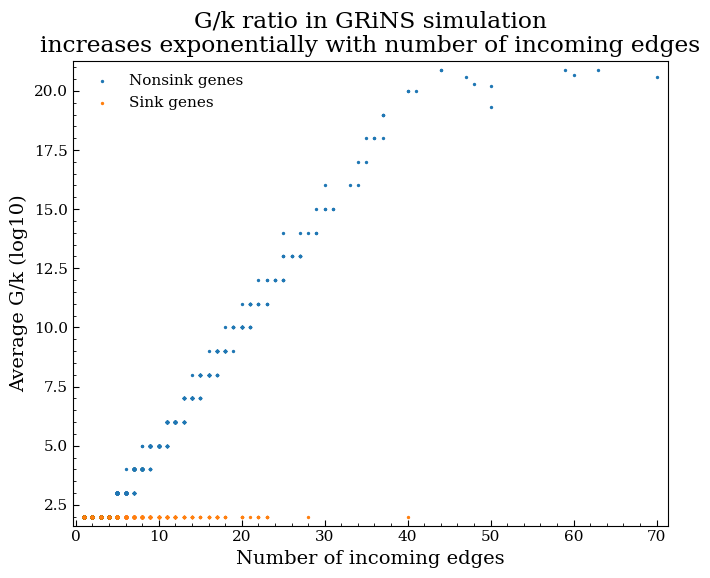

In [24]:
plt.figure(figsize=(7,6))
plt.scatter(merged_nonsink_df["counts"],np.log10(100*merged_nonsink_df["Minimum"]),s=2,label="Nonsink genes") # Max is 100x larger than min, so avg is 50x -> but divide by k (avg is always 0.5), so 100x
plt.scatter(merged_sink_df["counts"],np.log10(100*merged_sink_df["Minimum"]),s=2,label="Sink genes")
plt.xlabel("Number of incoming edges")
plt.ylabel("Average G/k (log10)")
plt.legend()
plt.title("G/k ratio in GRiNS simulation\nincreases exponentially with number of incoming edges")
plt.tight_layout()
plt.savefig(f"../Prep_Data/Plots/{grn_file}/G_edges.png")
plt.show()

## Self Pert Graph:

In [8]:
grn_file = "doro_abcd_only"

In [10]:
norman_data = sc.read_h5ad(f"../Data/Experimental/Norman19/perturb_norm_subset_{grn_file}.h5ad")
replogle_data = sc.read_h5ad(f"../Data/Experimental/Replogle22/perturb_norm_subset_{grn_file}.h5ad")
grins_G = sc.read_h5ad(f"../Data/Projects/{grn_file}/001/perturb_norm_pert.h5ad")


In [ ]:
cs = [1,2,3]#,3,3]
names = ["Replogle22","Norman19","only G"]#,"full equation","G and k"]
datasets = [replogle_data,norman_data,grins_G]#,grins_eq,grins_Gk]

In [25]:
logfc_dfs = []
for dataset in datasets:
    sc.tl.rank_genes_groups(dataset,groupby="perturbation",reference="ctrl",key_added="vs_ctrl",layer="log1p")
    perts = list(dataset.obs["perturbation"].unique())
    perts.remove("ctrl")
    self_logfcs = []
    for pert in perts:
        pgenes = pert.split("_")
        self_logfcs.append(np.mean([dataset.uns["vs_ctrl"]["logfoldchanges"][pert][dataset.uns["vs_ctrl"]["names"][pert]==pgene] for pgene in pgenes]))
    logfc_dfs.append(pd.DataFrame({"Perturbation":perts,"Self log2FC":self_logfcs}).sort_values(by="Self log2FC"))    


/storage/mi/sommereg03/vbsc_2/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/storage/mi/sommereg03/vbsc_2/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/storage/mi/sommereg03/vbsc_2/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:463: PerformanceWarning: Da

In [32]:
logfc_exp = pd.concat(logfc_dfs[:2]).sort_values(by="Self log2FC").reset_index()
# Sort logfc_df of every dataset according to order in experimental data
key = pd.Series({k:v for v,k in enumerate(logfc_exp["Perturbation"].unique())})
for i in range(len(logfc_dfs)):
    logfc_dfs[i] = logfc_dfs[i].sort_values(by="Perturbation",key=key.reindex).reset_index()

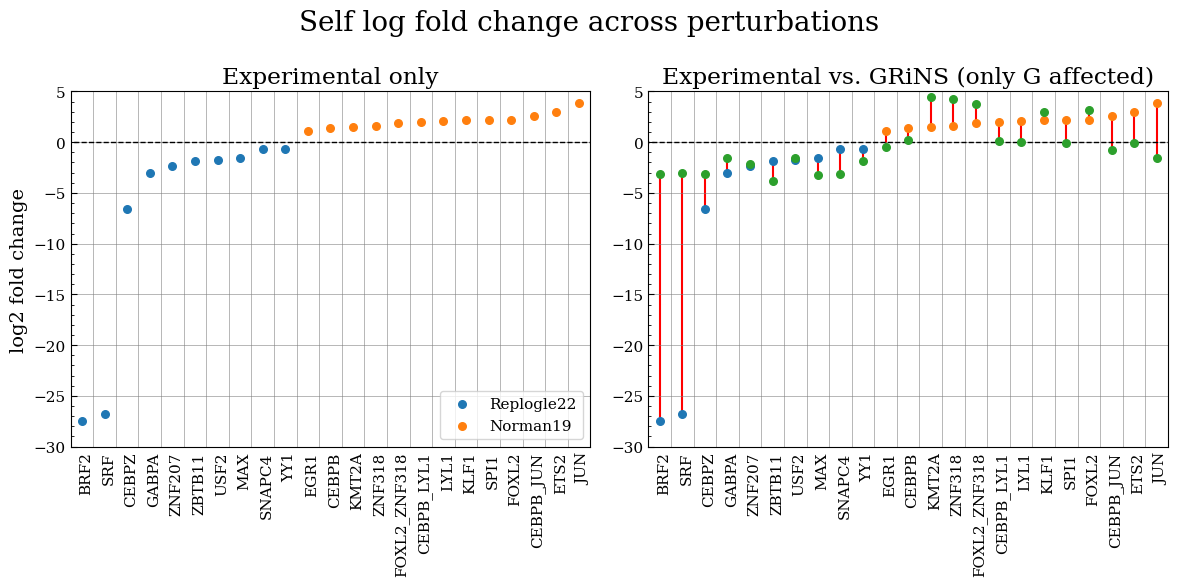

In [129]:
fig, axs = plt.subplots(1,len(names)-1,figsize=((len(names)-1)*6,6))
s=30
for i in range(len(names)-1):
    axs[i].hlines(0,-1,logfc_exp.shape[0],linestyles="dashed",lw=1,color="black")
    axs[i].scatter(range(logfc_dfs[0].shape[0]),logfc_dfs[0]["Self log2FC"],label="Replogle22",s=s,zorder=2)
    axs[i].scatter(range(logfc_dfs[0].shape[0],logfc_dfs[0].shape[0]+logfc_dfs[1].shape[0]),logfc_dfs[1]["Self log2FC"],label="Norman19",s=s,zorder=2)
    if i>0:
        axs[i].scatter(range(logfc_dfs[i+1].shape[0]),logfc_dfs[i+1]["Self log2FC"],label=names[i+1],s=s,zorder=2)
        axs[i].set_title(f"Experimental vs. GRiNS ({names[i+1]} affected)")
        for r in range(logfc_exp.shape[0]):
            axs[i].vlines(r,np.min([logfc_exp.loc[r,"Self log2FC"],logfc_dfs[i+1].loc[r,"Self log2FC"]]),np.max([logfc_exp.loc[r,"Self log2FC"],logfc_dfs[i+1].loc[r,"Self log2FC"]]),color="red",lw=1.5,zorder=1)
    else:
        axs[0].set_title("Experimental only")
        axs[0].set_ylabel("log2 fold change")
        axs[0].legend(loc="lower right",frameon=True)
    axs[i].set_xticks([0.5+x for x in range(logfc_exp.shape[0])],ha="right",labels=logfc_exp["Perturbation"])
    axs[i].tick_params(axis='x', labelrotation=90)
    axs[i].tick_params(axis='x', which=u'both',length=0)
    axs[i].grid(c="grey",lw=0.4)
    axs[i].set_ylim(-30,5)
    axs[i].set_xlim(-0.5,logfc_exp.shape[0]-0.5)
plt.suptitle("Self log fold change across perturbations")
plt.tight_layout()
plt.savefig(f"../Prep_Data/Plots/{grn_file}/self_logfc.png")
plt.show()